# Benchmark: TTA vs No-TTA (CLIP Models)

**Objetivo:** Comparar o impacto do Test-Time Augmentation (TTA) na accuracy e no tempo de inferencia dos modelos CLIP.

O TTA aplica 3 augmentations (base, flip horizontal, color jitter) e faz media dos embeddings. Melhora a robustez mas aumenta o tempo de inferencia.

Metricas:
- Top-1 Accuracy com/sem TTA
- Top-5 Accuracy com/sem TTA
- Tempo medio de inferencia com/sem TTA
- Speedup (no-TTA / TTA)


In [1]:
import sys
import os
import json
import time
import warnings
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm import tqdm

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (14, 6)

PROJECT_ROOT = Path(".").resolve().parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))

print(f"Project root: {PROJECT_ROOT}")
print(f"Setup concluido")

Project root: /home/eduardo/MIA/2/PROJ
Setup concluido


## 1. Carregar Test Set


In [2]:
from cnn_dataset import DeepFashionCategoryDataset, get_val_transforms, CAT_NAMES, NUM_CLASSES

DATA_ROOT = str(PROJECT_ROOT / "deepfashion")

test_ds = DeepFashionCategoryDataset(DATA_ROOT, split="test", transform=get_val_transforms())
print(f"Test set: {len(test_ds)} amostras")
print(f"{NUM_CLASSES} categorias")


[Dataset] Cache carregado: 40000 samples (test)
Test set: 40000 amostras
50 categorias


## 2. Amostra para Testes

O TTA e mais lento. Para comparacoes justas, usamos a mesma amostra para ambas as condicoes.


In [3]:
USE_FULL_TESTSET = False
SAMPLE_SIZE = 500

if USE_FULL_TESTSET:
    eval_indices = list(range(len(test_ds)))
    print(f"Usando test set completo: {len(eval_indices)} amostras")
else:
    import random
    random.seed(42)
    eval_indices = random.sample(range(len(test_ds)), SAMPLE_SIZE)
    print(f"Usando amostra: {len(eval_indices)} amostras")


Usando amostra: 500 amostras


## 3. Avaliar CLIP com e sem TTA

Para cada modelo CLIP, corremos o benchmark duas vezes: com TTA e sem TTA.


In [4]:
from predictor import FashionPredictor

CLIP_MODELS = {
    "patrickjohncyh/fashion-clip": "Fashion-CLIP",
    "openai/clip-vit-base-patch32": "CLIP ViT-B/32",
    "openai/clip-vit-base-patch16": "CLIP ViT-B/16",
    "laion/CLIP-ViT-B-32-laion2B-s34B-b79K": "CLIP ViT-B/32 (LAION-2B)",
    "openai/clip-vit-large-patch14": "CLIP ViT-L/14",
}

def evaluate_model(model_key, model_name, indices, use_tta):
    """Avalia um modelo CLIP com ou sem TTA."""
    print(f"\n{'='*60}")
    print(f"Modelo: {model_name} | TTA: {'ON' if use_tta else 'OFF'}")
    print(f"{'='*60}")
    
    predictor = FashionPredictor(data_root=DATA_ROOT, model_name=model_key, use_tta=use_tta)
    
    correct_top1 = 0
    correct_top5 = 0
    times = []
    all_preds = []
    all_labels = []
    
    tta_label = "TTA" if use_tta else "No-TTA"
    for idx in tqdm(indices, desc=f"{model_name} ({tta_label})"):
        img, label = test_ds[idx]
        img_path = test_ds.samples[idx]["path"]
        img_path_full = Path(DATA_ROOT) / img_path
        
        start = time.time()
        pred = predictor.predict(img_path_full, top_k=5, use_tta=use_tta)
        times.append(time.time() - start)
        
        pred_label = pred["category"]["label"]
        pred_top5 = [c["label"] for c in pred["category"]["top_k"]]
        true_label = CAT_NAMES[label]
        
        all_preds.append(pred_label)
        all_labels.append(true_label)
        
        if pred_label == true_label:
            correct_top1 += 1
        if true_label in pred_top5:
            correct_top5 += 1
    
    n = len(indices)
    results = {
        "model": model_name,
        "tta": use_tta,
        "top1_acc": correct_top1 / n,
        "top5_acc": correct_top5 / n,
        "avg_time": np.mean(times),
        "total_time": np.sum(times),
        "n_samples": n,
        "predictions": all_preds,
        "labels": all_labels,
    }
    
    print(f"  Top-1: {results['top1_acc']:.4f}")
    print(f"  Top-5: {results['top5_acc']:.4f}")
    print(f"  Tempo medio: {results['avg_time']*1000:.1f}ms")
    
    import torch
    del predictor
    torch.cuda.empty_cache()
    
    return results

# Corre o benchmark para todos os modelos
all_results = []

for key, name in CLIP_MODELS.items():
    try:
        # Sem TTA
        res_no_tta = evaluate_model(key, name, eval_indices, use_tta=False)
        all_results.append(res_no_tta)
        
        # Com TTA
        res_tta = evaluate_model(key, name, eval_indices, use_tta=True)
        all_results.append(res_tta)
    except Exception as e:
        print(f"  Erro em {name}: {e}")



Modelo: Fashion-CLIP | TTA: OFF
[Predictor] A carregar modelo patrickjohncyh/fashion-clip em cuda…


Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


[Predictor] A construir text banks…
[Predictor] Pronto. 50 categorias, 554 atributos, 18 cores.


Fashion-CLIP (No-TTA): 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 500/500 [00:06<00:00, 76.08it/s]


  Top-1: 0.4240
  Top-5: 0.8560
  Tempo medio: 11.8ms

Modelo: Fashion-CLIP | TTA: ON
[Predictor] A carregar modelo patrickjohncyh/fashion-clip em cuda…


...

  Top-1: 0.4300
  Top-5: 0.8660
  Tempo medio: 23.1ms

Modelo: CLIP ViT-L/14 | TTA: OFF
[Predictor] A carregar modelo openai/clip-vit-large-patch14 em cuda…
[Predictor] A construir text banks…
[Predictor] Pronto. 50 categorias, 554 atributos, 18 cores.


CLIP ViT-L/14 (No-TTA): 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 500/500 [00:24<00:00, 20.41it/s]


  Top-1: 0.3680
  Top-5: 0.7360
  Tempo medio: 47.4ms

Modelo: CLIP ViT-L/14 | TTA: ON
[Predictor] A carregar modelo openai/clip-vit-large-patch14 em cuda…
[Predictor] A construir text banks…
[Predictor] Pronto. 50 categorias, 554 atributos, 18 cores.


CLIP ViT-L/14 (TTA): 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 500/500 [01:07<00:00,  7.37it/s]

  Top-1: 0.3880
  Top-5: 0.7460
  Tempo medio: 133.5ms


## 4. Tabela Comparativa: TTA vs No-TTA


In [5]:
# Organiza os resultados por modelo
model_groups = {}
for r in all_results:
    model = r["model"]
    if model not in model_groups:
        model_groups[model] = {}
    model_groups[model]["tta" if r["tta"] else "no_tta"] = r

# Constroi a tabela comparativa
rows = []
for model in CLIP_MODELS.values():
    if model not in model_groups:
        continue
    
    no_tta = model_groups[model].get("no_tta", {})
    tta = model_groups[model].get("tta", {})
    
    if not no_tta or not tta:
        continue
    
    top1_diff = tta["top1_acc"] - no_tta["top1_acc"]
    top5_diff = tta["top5_acc"] - no_tta["top5_acc"]
    speedup = no_tta["avg_time"] / tta["avg_time"]
    slowdown = tta["avg_time"] / no_tta["avg_time"]
    
    rows.append({
        "Modelo": model,
        "Top-1 (No-TTA)": f"{no_tta['top1_acc']:.4f}",
        "Top-1 (TTA)": f"{tta['top1_acc']:.4f}",
        "Delta Top-1": f"{top1_diff:+.4f}",
        "Top-5 (No-TTA)": f"{no_tta['top5_acc']:.4f}",
        "Top-5 (TTA)": f"{tta['top5_acc']:.4f}",
        "Delta Top-5": f"{top5_diff:+.4f}",
        "Tempo No-TTA (ms)": f"{no_tta['avg_time']*1000:.1f}",
        "Tempo TTA (ms)": f"{tta['avg_time']*1000:.1f}",
        "Slowdown": f"{slowdown:.1f}x",
    })

df = pd.DataFrame(rows)
print("\n=== TTA vs No-TTA: Comparacao ===")
display(df)



=== TTA vs No-TTA: Comparacao ===


,Modelo,Top-1 (No-TTA),Top-1 (TTA),Delta Top-1,Top-5 (No-TTA),Top-5 (TTA),Delta Top-5,Tempo No-TTA (ms),Tempo TTA (ms),Slowdown
0,Fashion-CLIP,0.4240,0.4320,+0.0080,0.8560,0.8620,+0.0060,11.8,21.7,1.8x
1,CLIP ViT-B/32,0.3480,0.3620,+0.0140,0.7640,0.7640,+0.0000,12.0,22.0,1.8x
2,CLIP ViT-B/16,0.3340,0.3400,+0.0060,0.7720,0.7760,+0.0040,17.8,38.4,2.2x
3,CLIP ViT-B/32 (LAION-2B),0.4180,0.4300,+0.0120,0.8600,0.8660,+0.0060,12.0,23.1,1.9x
4,CLIP ViT-L/14,0.3680,0.3880,+0.0200,0.7360,0.7460,+0.0100,47.4,133.5,2.8x


## 5. Visualizacao: Impacto do TTA na Accuracy


Task was destroyed but it is pending!
task: <Task pending name='Task-123' coro=<_async_in_context.<locals>.run_in_context() done, defined at /home/eduardo/.local/lib/python3.12/site-packages/ipykernel/utils.py:57> wait_for=<Task pending name='Task-124' coro=<Kernel.shell_main() running at /home/eduardo/.local/lib/python3.12/site-packages/ipykernel/kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at /home/eduardo/.local/lib/python3.12/site-packages/zmq/eventloop/zmqstream.py:563]>
Task was destroyed but it is pending!
task: <Task pending name='Task-124' coro=<Kernel.shell_main() running at /home/eduardo/.local/lib/python3.12/site-packages/ipykernel/kernelbase.py:597> cb=[Task.task_wakeup()]>


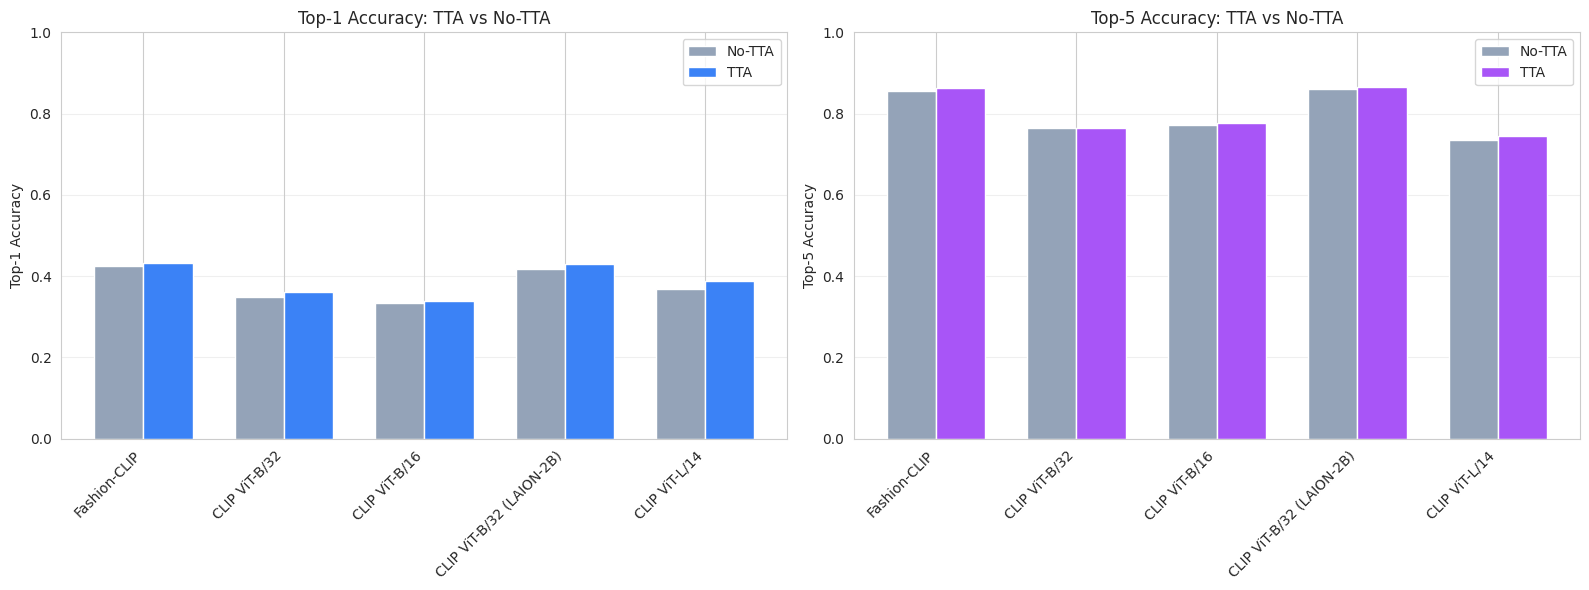

Grafico gravado: tta_accuracy_comparison.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

models = [r["Modelo"] for r in rows]
top1_no_tta = [float(r["Top-1 (No-TTA)"]) for r in rows]
top1_tta = [float(r["Top-1 (TTA)"]) for r in rows]
top5_no_tta = [float(r["Top-5 (No-TTA)"]) for r in rows]
top5_tta = [float(r["Top-5 (TTA)"]) for r in rows]

x = np.arange(len(models))
width = 0.35

# Top-1
axes[0].bar(x - width/2, top1_no_tta, width, label="No-TTA", color="#94a3b8")
axes[0].bar(x + width/2, top1_tta, width, label="TTA", color="#3b82f6")
axes[0].set_ylabel("Top-1 Accuracy")
axes[0].set_title("Top-1 Accuracy: TTA vs No-TTA")
axes[0].set_xticks(x)
axes[0].set_xticklabels(models, rotation=45, ha="right")
axes[0].legend()
axes[0].set_ylim(0, 1)
axes[0].grid(axis="y", alpha=0.3)

# Top-5
axes[1].bar(x - width/2, top5_no_tta, width, label="No-TTA", color="#94a3b8")
axes[1].bar(x + width/2, top5_tta, width, label="TTA", color="#a855f7")
axes[1].set_ylabel("Top-5 Accuracy")
axes[1].set_title("Top-5 Accuracy: TTA vs No-TTA")
axes[1].set_xticks(x)
axes[1].set_xticklabels(models, rotation=45, ha="right")
axes[1].legend()
axes[1].set_ylim(0, 1)
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("tta_accuracy_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Grafico gravado: tta_accuracy_comparison.png")


## 6. Visualizacao: Impacto do TTA no Tempo


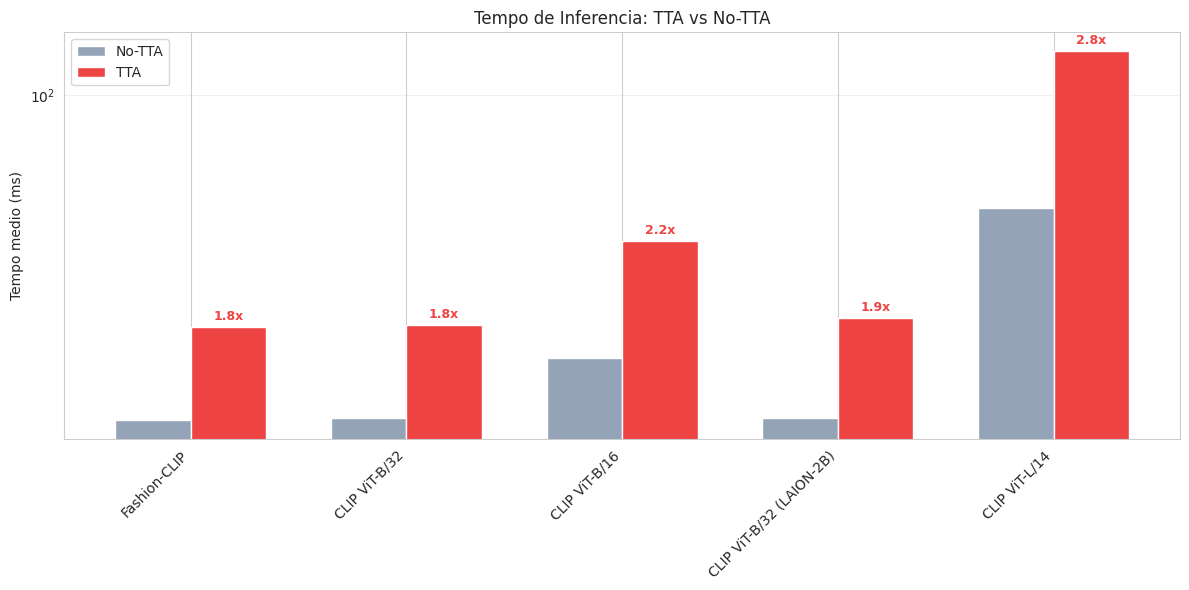

Grafico gravado: tta_time_comparison.png


In [9]:
fig, ax = plt.subplots(figsize=(12, 6))

time_no_tta = [float(r["Tempo No-TTA (ms)"]) for r in rows]
time_tta = [float(r["Tempo TTA (ms)"]) for r in rows]

x = np.arange(len(models))
width = 0.35

bars1 = ax.bar(x - width/2, time_no_tta, width, label="No-TTA", color="#94a3b8")
bars2 = ax.bar(x + width/2, time_tta, width, label="TTA", color="#ef4444")

# Adiciona anotacoes de slowdown
for i, r in enumerate(rows):
    slowdown = r["Slowdown"]
    ax.annotate(
        f"{slowdown}",
        xy=(x[i] + width/2, time_tta[i]),
        xytext=(0, 5),
        textcoords="offset points",
        ha="center",
        fontsize=9,
        color="#ef4444",
        fontweight="bold"
    )

ax.set_ylabel("Tempo medio (ms)")
ax.set_title("Tempo de Inferencia: TTA vs No-TTA")
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=45, ha="right")
ax.legend()
ax.set_yscale("log")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("tta_time_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Grafico gravado: tta_time_comparison.png")


## 7. Scatter Plot: Trade-off Accuracy vs Tempo

Cada ponto representa um modelo. Eixo X = tempo, Eixo Y = accuracy. TTA = azul, No-TTA = cinza.


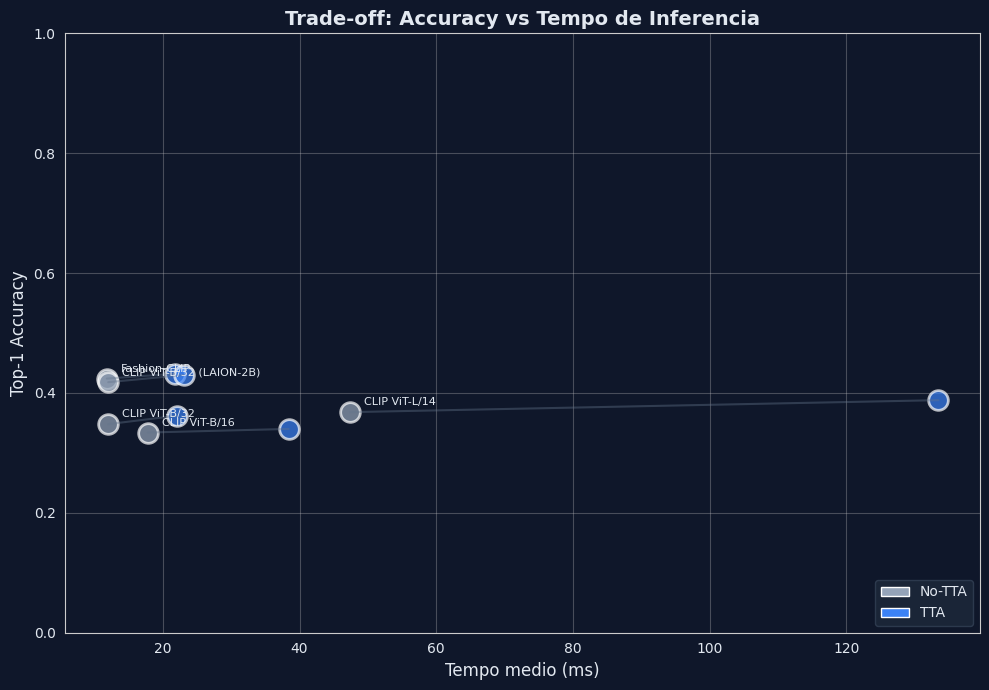

Grafico gravado: tta_tradeoff.png


In [10]:
fig, ax = plt.subplots(figsize=(10, 7))

for i, r in enumerate(rows):
    # No-TTA
    ax.scatter(
        float(r["Tempo No-TTA (ms)"]),
        float(r["Top-1 (No-TTA)"]),
        s=200,
        color="#94a3b8",
        alpha=0.7,
        edgecolors="white",
        linewidth=2,
    )
    # TTA
    ax.scatter(
        float(r["Tempo TTA (ms)"]),
        float(r["Top-1 (TTA)"]),
        s=200,
        color="#3b82f6",
        alpha=0.7,
        edgecolors="white",
        linewidth=2,
    )
    
    # Linha conectando os dois pontos
    ax.plot(
        [float(r["Tempo No-TTA (ms)"]), float(r["Tempo TTA (ms)"])],
        [float(r["Top-1 (No-TTA)"]), float(r["Top-1 (TTA)"])],
        "-",
        color="#64748b",
        alpha=0.4,
        linewidth=1.5
    )
    
    # Label
    ax.annotate(
        r["Modelo"],
        xy=(float(r["Tempo No-TTA (ms)"]), float(r["Top-1 (No-TTA)"])),
        xytext=(10, 5),
        textcoords="offset points",
        fontsize=8,
        color="#e2e8f0"
    )

ax.set_xlabel("Tempo medio (ms)", fontsize=12)
ax.set_ylabel("Top-1 Accuracy", fontsize=12)
ax.set_title("Trade-off: Accuracy vs Tempo de Inferencia", fontsize=14, fontweight="bold")
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3)
ax.set_facecolor("#0f172a")
fig.patch.set_facecolor("#0f172a")
ax.tick_params(colors="#e2e8f0")
ax.xaxis.label.set_color("#e2e8f0")
ax.yaxis.label.set_color("#e2e8f0")
ax.title.set_color("#e2e8f0")

# Legenda manual
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#94a3b8", edgecolor="white", label="No-TTA"),
    Patch(facecolor="#3b82f6", edgecolor="white", label="TTA"),
]
ax.legend(handles=legend_elements, loc="lower right", facecolor="#1e293b", edgecolor="#334155", labelcolor="#e2e8f0")

plt.tight_layout()
plt.savefig("tta_tradeoff.png", dpi=150, bbox_inches="tight", facecolor="#0f172a")
plt.show()
print("Grafico gravado: tta_tradeoff.png")


## 8. Guardar Resultados


In [11]:
output = {
    "benchmark_type": "tta_vs_no_tta",
    "benchmark_date": pd.Timestamp.now().isoformat(),
    "test_samples": len(eval_indices),
    "models": [
        {
            "model": r["model"],
            "tta": r["tta"],
            "top1_acc": float(r["top1_acc"]),
            "top5_acc": float(r["top5_acc"]),
            "avg_time_ms": float(r["avg_time"]*1000),
            "n_samples": r["n_samples"],
        }
        for r in all_results
    ],
    "comparisons": [
        {
            "model": r["Modelo"],
            "top1_diff": float(r["Delta Top-1"]),
            "top5_diff": float(r["Delta Top-5"]),
            "slowdown": r["Slowdown"],
        }
        for r in rows
    ]
}

with open("benchmark_tta_results.json", "w", encoding="utf-8") as f:
    json.dump(output, f, indent=2, ensure_ascii=False)

print(f"Resultados gravados: benchmark_tta_results.json")
print(f"\nBenchmark TTA concluido!")


Resultados gravados: benchmark_tta_results.json

Benchmark TTA concluido!
